## Setup and Data Loading

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Resolve CSV path
csv_path = Path('avg_fid_summary_rebuttal.csv')
if not csv_path.exists():
    raise FileNotFoundError(f"Run extract_avg_fid_rebuttal.py first to generate {csv_path}")

print(f"Reading: {csv_path}")
df = pd.read_csv(csv_path)

print(f"\nDatasets: {sorted(df['dataset'].unique())}")
print(f"Num eigenvalues: {sorted(df['num_eigs'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}")
print(f"\nShape: {df.shape}")
df.head()

Reading: avg_fid_summary_rebuttal.csv

Datasets: ['cifar10', 'fmnist']
Num eigenvalues: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Seeds: [np.int64(123), np.int64(234), np.int64(345)]

Shape: (30, 8)

Datasets: ['cifar10', 'fmnist']
Num eigenvalues: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Seeds: [np.int64(123), np.int64(234), np.int64(345)]

Shape: (30, 8)


,dataset,num_eigs,seed,avg_fid@task0,avg_fid@task1,avg_fid@task2,avg_fid@task3,avg_fid@task4
0,cifar10,1,123,36.072643,56.346457,58.041838,59.097063,57.045841
1,cifar10,1,234,40.232716,51.452454,57.734917,57.076530,55.492197
2,cifar10,1,345,48.398693,54.107698,56.844280,58.152178,60.618295
3,cifar10,2,123,36.072643,49.505260,51.761954,52.174240,55.340721
4,cifar10,2,234,40.232716,42.583408,51.685010,50.818072,54.563718


## Per-Dataset FID Plots (Grouped by num_eigs)

For each dataset, create separate plots for each `num_eigs` value, showing FID vs Task with mean ± SE across seeds.

Saved: plots_rebuttal/fid_vs_task_cifar10_eig1.pdf


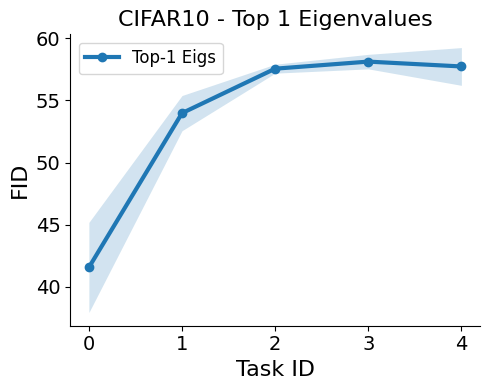

Saved: plots_rebuttal/fid_vs_task_cifar10_eig2.pdf


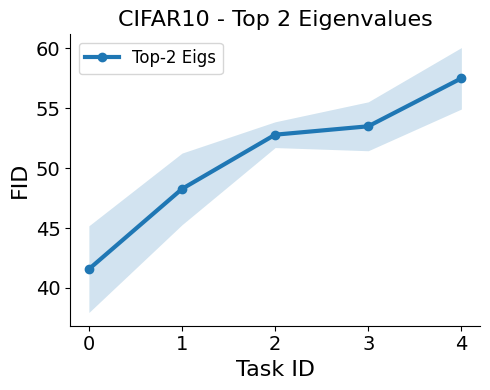

Saved: plots_rebuttal/fid_vs_task_cifar10_eig3.pdf


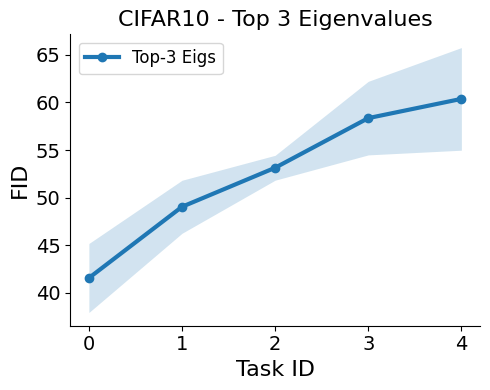

Saved: plots_rebuttal/fid_vs_task_cifar10_eig4.pdf


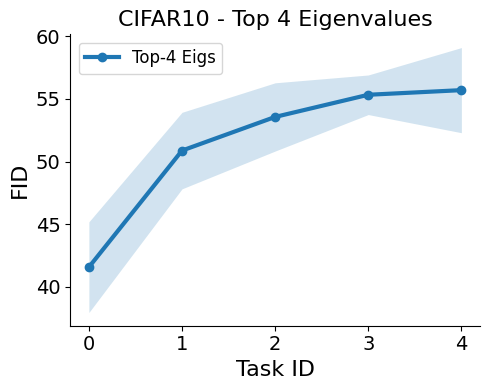

Saved: plots_rebuttal/fid_vs_task_cifar10_eig5.pdf


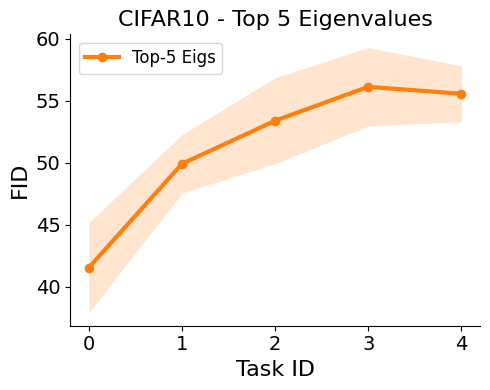

Saved: plots_rebuttal/fid_vs_task_fmnist_eig1.pdf


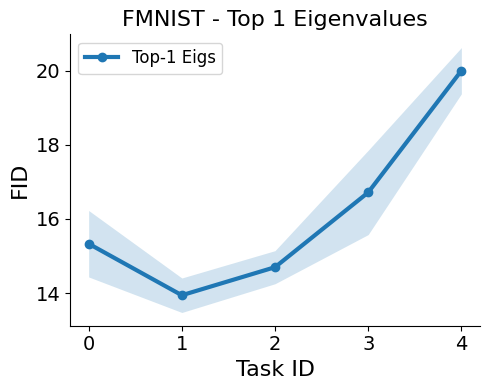

Saved: plots_rebuttal/fid_vs_task_fmnist_eig2.pdf


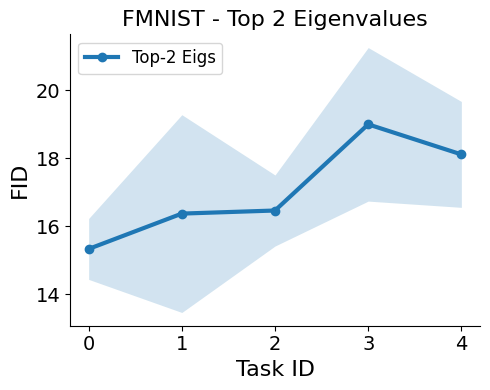

Saved: plots_rebuttal/fid_vs_task_fmnist_eig3.pdf


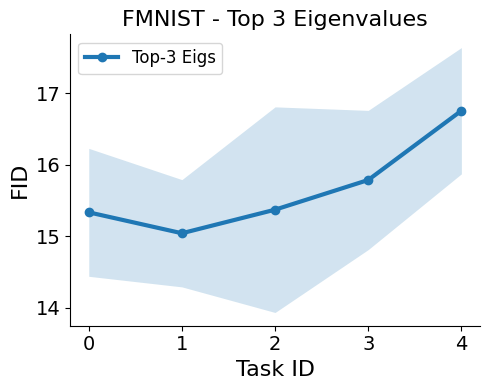

Saved: plots_rebuttal/fid_vs_task_fmnist_eig4.pdf


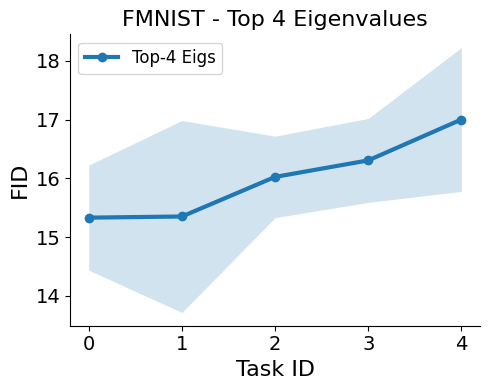

Saved: plots_rebuttal/fid_vs_task_fmnist_eig5.pdf


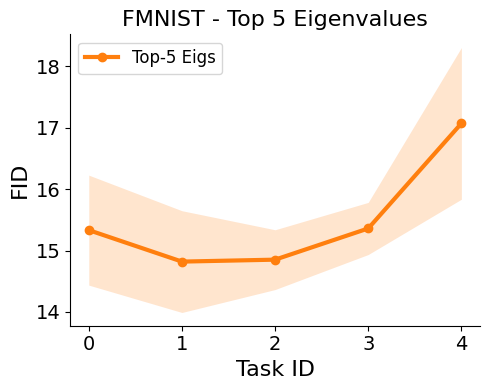

In [2]:
# Identify task columns
task_cols = [c for c in df.columns if c.startswith('avg_fid@task')]
if not task_cols:
    raise ValueError("No 'avg_fid@task*' columns found in CSV.")

col_to_id = lambda c: int(c.split('@task')[1])
task_cols = sorted(task_cols, key=col_to_id)

# Create output directory
plots_dir = Path('plots_rebuttal')
plots_dir.mkdir(parents=True, exist_ok=True)

# Color mapping for different num_eigs values
def get_color_for_eigs(num_eigs):
    colors = {
        1: '#1f77b4',   # blue
        5: '#ff7f0e',   # orange
        10: '#2ca02c',  # green
        20: '#d62728',  # red
        50: '#9467bd',  # purple
        100: '#8c564b', # brown
    }
    return colors.get(num_eigs, None)

# Generate plots per dataset and num_eigs
for dataset in sorted(df['dataset'].unique()):
    dataset_df = df[df['dataset'] == dataset]
    
    for num_eigs in sorted(dataset_df['num_eigs'].unique()):
        sub = dataset_df[dataset_df['num_eigs'] == num_eigs]
        
        if sub.empty:
            continue
        
        fig, ax = plt.subplots(figsize=(5, 4))
        
        # Calculate mean and SE across seeds
        means = sub[task_cols].mean(axis=0, skipna=True)
        n_seeds = sub[task_cols].count(axis=0)
        stds = sub[task_cols].std(axis=0, skipna=True)
        se = stds / np.sqrt(n_seeds.replace(0, np.nan))  # Standard error
        
        # Filter to tasks with data
        valid = ~means.isna()
        if valid.sum() == 0:
            plt.close(fig)
            continue
        
        x_ids = [col_to_id(c) for c in means.index[valid]]
        y = means[valid].to_numpy(dtype=float)
        s = se[valid].to_numpy(dtype=float)
        s = np.nan_to_num(s, nan=0.0)
        
        # Plot
        color = get_color_for_eigs(num_eigs)
        label = f"Top-{num_eigs} Eigs"
        (line,) = ax.plot(
            x_ids,
            y,
            label=label,
            linewidth=3.0,
            linestyle='-',
            marker='o',
            color=color,
            markersize=6,
        )
        ax.fill_between(x_ids, y - s, y + s, color=line.get_color(), alpha=0.2, linewidth=0)
        
        # Styling
        ax.set_xlabel('Task ID', fontsize=16)
        ax.set_ylabel('FID', fontsize=16)
        ax.set_title(f'{dataset.upper()} - Top {num_eigs} Eigenvalues', fontsize=16)
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # X-axis ticks
        if str(dataset).lower() == 'imagenet64':
            xticks_5 = list(range(0, max(x_ids) + 1, 5))
            ax.set_xticks(xticks_5)
        else:
            ax.set_xticks(x_ids)
        
        ax.tick_params(axis='both', labelsize=14)
        ax.legend(fontsize=12, loc='best')
        
        fig.tight_layout()
        
        # Save
        out_path = plots_dir / f'fid_vs_task_{dataset}_eig{num_eigs}.pdf'
        fig.savefig(out_path, dpi=200, format='pdf')
        print(f"Saved: {out_path}")
        plt.show()
        plt.close()

## Combined Plots: All num_eigs on Same Plot per Dataset

Show all eigenvalue counts on the same plot for easy comparison.

Saved: plots_rebuttal/fid_vs_task_cifar10_all_eigs.pdf


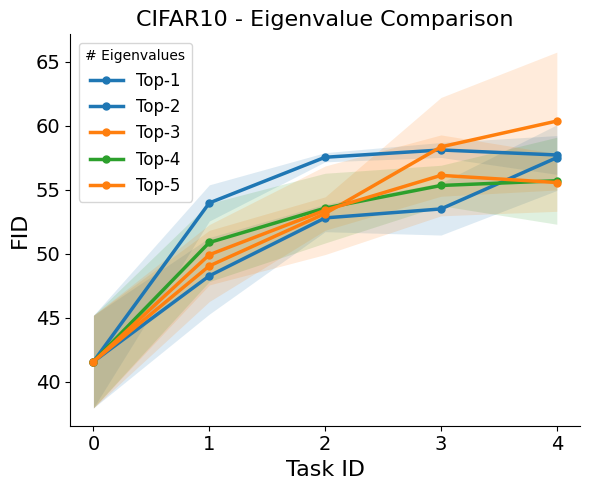

Saved: plots_rebuttal/fid_vs_task_fmnist_all_eigs.pdf


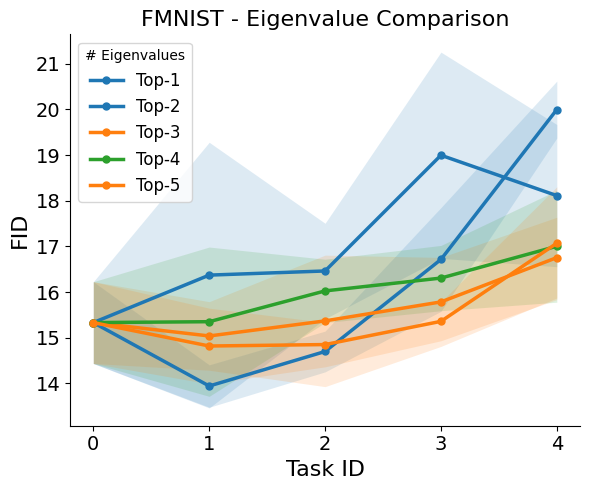

In [3]:
# Generate combined plots per dataset
for dataset in sorted(df['dataset'].unique()):
    dataset_df = df[df['dataset'] == dataset]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    any_line = False
    
    for num_eigs in sorted(dataset_df['num_eigs'].unique()):
        sub = dataset_df[dataset_df['num_eigs'] == num_eigs]
        
        if sub.empty:
            continue
        
        # Calculate statistics
        means = sub[task_cols].mean(axis=0, skipna=True)
        n_seeds = sub[task_cols].count(axis=0)
        stds = sub[task_cols].std(axis=0, skipna=True)
        se = stds / np.sqrt(n_seeds.replace(0, np.nan))
        
        valid = ~means.isna()
        if valid.sum() == 0:
            continue
        
        x_ids = [col_to_id(c) for c in means.index[valid]]
        y = means[valid].to_numpy(dtype=float)
        s = se[valid].to_numpy(dtype=float)
        s = np.nan_to_num(s, nan=0.0)
        
        # Plot
        color = get_color_for_eigs(num_eigs)
        label = f"Top-{num_eigs}"
        (line,) = ax.plot(
            x_ids,
            y,
            label=label,
            linewidth=2.5,
            linestyle='-',
            marker='o',
            color=color,
            markersize=5,
        )
        ax.fill_between(x_ids, y - s, y + s, color=line.get_color(), alpha=0.15, linewidth=0)
        any_line = True
    
    if not any_line:
        plt.close(fig)
        continue
    
    # Styling
    ax.set_xlabel('Task ID', fontsize=16)
    ax.set_ylabel('FID', fontsize=16)
    ax.set_title(f'{dataset.upper()} - Eigenvalue Comparison', fontsize=16)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Get all x values for consistent ticks
    all_x = []
    for num_eigs in dataset_df['num_eigs'].unique():
        sub = dataset_df[dataset_df['num_eigs'] == num_eigs]
        means = sub[task_cols].mean(axis=0, skipna=True)
        valid = ~means.isna()
        all_x.extend([col_to_id(c) for c in means.index[valid]])
    
    if all_x:
        if str(dataset).lower() == 'imagenet64':
            xticks = list(range(0, max(all_x) + 1, 5))
        else:
            xticks = sorted(set(all_x))
        ax.set_xticks(xticks)
    
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=12, loc='best', title='# Eigenvalues')
    
    fig.tight_layout()
    
    # Save
    out_path = plots_dir / f'fid_vs_task_{dataset}_all_eigs.pdf'
    fig.savefig(out_path, dpi=200, format='pdf')
    print(f"Saved: {out_path}")
    plt.show()
    plt.close()

## Average Forgetting Table

Compute average forgetting from triangle CSVs for each dataset and num_eigs configuration.

In [4]:
# Locate fid_triangles directory
tri_dir = Path('fid_triangles_rebuttal')
if not tri_dir.exists():
    print(f"Triangle directory not found. Run extract_fid_triangle_rebuttal.py first.")
else:
    print(f"Reading triangle CSVs from: {tri_dir}")
    
    # Helper to parse dataset, num_eigs, seed from filename 'dataset_eig{num}_{seed}.csv'
    def parse_triangle_name(path: Path):
        stem = path.stem
        parts = stem.split('_')
        if len(parts) < 2:
            return stem, 0, None
        dataset = parts[0]
        
        # Extract num_eigs from 'eig{num}'
        num_eigs = 0
        for part in parts:
            if part.startswith('eig'):
                try:
                    num_eigs = int(part[3:])
                    break
                except ValueError:
                    pass
        
        # Last part is seed
        seed = None
        try:
            seed = int(parts[-1])
        except ValueError:
            pass
        
        return dataset, num_eigs, seed
    
    # Compute average forgetting for a triangle CSV
    def compute_avg_forgetting(csv_path: Path):
        df = pd.read_csv(csv_path)
        if 'task_id' not in df.columns:
            return None
        fid_cols = [c for c in df.columns if c.startswith('fid-task')]
        if not fid_cols:
            return None
        
        def col_idx(c: str) -> int:
            return int(c.split('fid-task')[1])
        
        fid_cols_sorted = sorted(fid_cols, key=col_idx)
        max_task_idx = col_idx(fid_cols_sorted[-1])
        
        df_sorted = df.sort_values('task_id')
        last_row = df_sorted.iloc[-1]
        
        num = 0.0
        count = 0
        for i in range(max_task_idx + 1):
            final_val = last_row.get(f'fid-task{i}', np.nan)
            diag_row = df_sorted[df_sorted['task_id'] == i]
            diag_val = diag_row[f'fid-task{i}'].iloc[0] if not diag_row.empty else np.nan
            if not pd.isna(final_val) and not pd.isna(diag_val):
                num += float(final_val) - float(diag_val)
                count += 1
        
        if count == 0:
            return None
        return num / count
    
    # Scan all triangle CSVs
    records = []
    for csv_file in sorted(tri_dir.glob('*.csv')):
        dataset, num_eigs, seed = parse_triangle_name(csv_file)
        f = compute_avg_forgetting(csv_file)
        if f is None:
            continue
        records.append({
            'dataset': dataset,
            'num_eigs': num_eigs,
            'seed': seed,
            'avg_forgetting': f,
        })
    
    if records:
        runs_df = pd.DataFrame.from_records(records)
        
        # Aggregate by dataset and num_eigs
        def agg_group(g: pd.DataFrame) -> pd.Series:
            n = g['avg_forgetting'].count()
            mean = g['avg_forgetting'].mean()
            se = g['avg_forgetting'].std(ddof=1) / math.sqrt(n) if n > 1 else float('nan')
            return pd.Series({'mean': mean, 'stderr': se, 'n_seeds': n})
        
        summary = runs_df.groupby(['dataset', 'num_eigs'], dropna=False).apply(agg_group).reset_index()
        summary['mean_pm_se'] = summary.apply(
            lambda r: f"{r['mean']:.3f} ± {r['stderr']:.3f}" if not pd.isna(r['stderr']) else f"{r['mean']:.3f}",
            axis=1
        )
        
        summary = summary.sort_values(['dataset', 'num_eigs']).reset_index(drop=True)
        
        out_csv = Path('avg_forgetting_table_rebuttal.csv')
        summary.to_csv(out_csv, index=False)
        print(f"\nSaved avg forgetting summary to: {out_csv}")
        display(summary)
    else:
        print("No forgetting values computed.")

Reading triangle CSVs from: fid_triangles_rebuttal

Saved avg forgetting summary to: avg_forgetting_table_rebuttal.csv

Saved avg forgetting summary to: avg_forgetting_table_rebuttal.csv


/tmp/ipykernel_3929039/144385660.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = runs_df.groupby(['dataset', 'num_eigs'], dropna=False).apply(agg_group).reset_index()


,dataset,num_eigs,mean,stderr,n_seeds,mean_pm_se
0,cifar10,1,14.342939,1.163127,3.0,14.343 ± 1.163
1,cifar10,2,15.945007,1.835622,3.0,15.945 ± 1.836
2,cifar10,3,17.702567,4.950558,3.0,17.703 ± 4.951
3,cifar10,4,13.015318,2.027971,3.0,13.015 ± 2.028
4,cifar10,5,12.636300,1.559426,3.0,12.636 ± 1.559
5,fmnist,1,5.728271,0.344682,3.0,5.728 ± 0.345
6,fmnist,2,3.815881,1.403438,3.0,3.816 ± 1.403
7,fmnist,3,2.850307,0.634119,3.0,2.850 ± 0.634
8,fmnist,4,2.914090,1.199217,3.0,2.914 ± 1.199
9,fmnist,5,2.889611,1.022664,3.0,2.890 ± 1.023


## Final FID Table

Extract final FID values (last task) for each configuration.

In [5]:
# Extract final FID values
final_fid_records = []

for dataset in df['dataset'].unique():
    dataset_df = df[df['dataset'] == dataset]
    
    for num_eigs in dataset_df['num_eigs'].unique():
        config_df = dataset_df[dataset_df['num_eigs'] == num_eigs]
        
        final_fid_values = []
        
        for _, row in config_df.iterrows():
            # Get the last non-NaN value from task columns
            row_values = [row[col] for col in reversed(task_cols)]
            final_value = None
            for val in row_values:
                if not pd.isna(val):
                    final_value = val
                    break
            
            if final_value is not None:
                final_fid_values.append(final_value)
        
        if final_fid_values:
            final_fid_records.append({
                'dataset': dataset,
                'num_eigs': num_eigs,
                'final_fid_values': final_fid_values
            })

# Compute statistics
def compute_final_fid_stats(fid_values):
    n = len(fid_values)
    mean = np.mean(fid_values)
    se = np.std(fid_values, ddof=1) / math.sqrt(n) if n > 1 else float('nan')
    return mean, se, n

final_fid_summary = []
for record in final_fid_records:
    mean, se, n = compute_final_fid_stats(record['final_fid_values'])
    
    if not pd.isna(se):
        mean_pm_se = f"{mean:.3f} ± {se:.3f}"
    else:
        mean_pm_se = f"{mean:.3f}"
    
    final_fid_summary.append({
        'dataset': record['dataset'],
        'num_eigs': record['num_eigs'],
        'mean': mean,
        'stderr': se,
        'n_seeds': n,
        'mean_pm_se': mean_pm_se
    })

final_fid_df = pd.DataFrame(final_fid_summary)
final_fid_df = final_fid_df.sort_values(['dataset', 'num_eigs']).reset_index(drop=True)

out_csv = Path('final_fid_table_rebuttal.csv')
final_fid_df.to_csv(out_csv, index=False)
print(f"\nSaved final FID summary to: {out_csv}")
display(final_fid_df)


Saved final FID summary to: final_fid_table_rebuttal.csv


,dataset,num_eigs,mean,stderr,n_seeds,mean_pm_se
0,cifar10,1,57.718778,1.517547,3,57.719 ± 1.518
1,cifar10,2,57.509285,2.566885,3,57.509 ± 2.567
2,cifar10,3,60.369492,5.386801,3,60.369 ± 5.387
3,cifar10,4,55.703364,3.399168,3,55.703 ± 3.399
4,cifar10,5,55.564139,2.250020,3,55.564 ± 2.250
5,fmnist,1,19.995383,0.623252,3,19.995 ± 0.623
6,fmnist,2,18.111356,1.556508,3,18.111 ± 1.557
7,fmnist,3,16.754582,0.883803,3,16.755 ± 0.884
8,fmnist,4,17.002979,1.224361,3,17.003 ± 1.224
9,fmnist,5,17.070024,1.234876,3,17.070 ± 1.235


## Combined Summary Table

Merge Final FID and Average Forgetting into a single table.

In [11]:
# Load or use existing forgetting data
# import tabulate
forgetting_csv = Path('avg_forgetting_table_rebuttal.csv')
if forgetting_csv.exists():
    forgetting_df = pd.read_csv(forgetting_csv)
    
    # Merge tables
    final_fid_clean = final_fid_df[['dataset', 'num_eigs', 'mean_pm_se']].rename(columns={'mean_pm_se': 'final_fid'})
    forgetting_clean = forgetting_df[['dataset', 'num_eigs', 'mean_pm_se']].rename(columns={'mean_pm_se': 'avg_forgetting'})
    
    combined_df = pd.merge(
        final_fid_clean,
        forgetting_clean,
        on=['dataset', 'num_eigs'],
        how='outer'
    )
    
    combined_df = combined_df.fillna('N/A')
    combined_df = combined_df.sort_values(['dataset', 'num_eigs']).reset_index(drop=True)
    
    out_csv = Path('combined_summary_rebuttal.csv')
    combined_df.to_csv(out_csv, index=False)
    print(f"\nSaved combined summary to: {out_csv}")
    display(combined_df)
    
    # Create multi-column markdown format with proper multi-level headers
    print("\n" + "="*80)
    print("MARKDOWN FORMAT (Multi-column with subheaders):")
    print("="*80 + "\n")
    
    # Separate datasets
    cifar10_df = combined_df[combined_df['dataset'] == 'cifar10'].reset_index(drop=True)
    fmnist_df = combined_df[combined_df['dataset'] == 'fmnist'].reset_index(drop=True)
    
    # Build the table manually for proper multi-level headers
    header1 = "| #Eigs | CIFAR-10 | | FMNIST | |"
    header2 = "| | Final FID | Avg Forgetting | Final FID | Avg Forgetting |"
    separator = "|:---:|:---:|:---:|:---:|:---:|"
    
    print(header1)
    print(header2)
    print(separator)
    
    max_rows = max(len(cifar10_df), len(fmnist_df))
    
    for i in range(max_rows):
        # Get num_eigs (should be same for both datasets at same index)
        if i < len(cifar10_df):
            num_eigs = cifar10_df.loc[i, 'num_eigs']
        elif i < len(fmnist_df):
            num_eigs = fmnist_df.loc[i, 'num_eigs']
        else:
            num_eigs = '-'
        
        # CIFAR-10 values
        if i < len(cifar10_df):
            c_fid = cifar10_df.loc[i, 'final_fid']
            c_forg = cifar10_df.loc[i, 'avg_forgetting']
        else:
            c_fid = '-'
            c_forg = '-'
        
        # FMNIST values
        if i < len(fmnist_df):
            f_fid = fmnist_df.loc[i, 'final_fid']
            f_forg = fmnist_df.loc[i, 'avg_forgetting']
        else:
            f_fid = '-'
            f_forg = '-'
        
        print(f"| {num_eigs} | {c_fid} | {c_forg} | {f_fid} | {f_forg} |")
else:
    print("Forgetting table not found. Skipping combined summary.")


Saved combined summary to: combined_summary_rebuttal.csv


,dataset,num_eigs,final_fid,avg_forgetting
0,cifar10,1,57.719 ± 1.518,14.343 ± 1.163
1,cifar10,2,57.509 ± 2.567,15.945 ± 1.836
2,cifar10,3,60.369 ± 5.387,17.703 ± 4.951
3,cifar10,4,55.703 ± 3.399,13.015 ± 2.028
4,cifar10,5,55.564 ± 2.250,12.636 ± 1.559
5,fmnist,1,19.995 ± 0.623,5.728 ± 0.345
6,fmnist,2,18.111 ± 1.557,3.816 ± 1.403
7,fmnist,3,16.755 ± 0.884,2.850 ± 0.634
8,fmnist,4,17.003 ± 1.224,2.914 ± 1.199
9,fmnist,5,17.070 ± 1.235,2.890 ± 1.023



MARKDOWN FORMAT (Multi-column with subheaders):

| #Eigs | CIFAR-10 | | FMNIST | |
| | Final FID | Avg Forgetting | Final FID | Avg Forgetting |
|:---:|:---:|:---:|:---:|:---:|
| 1 | 57.719 ± 1.518 | 14.343 ± 1.163 | 19.995 ± 0.623 | 5.728 ± 0.345 |
| 2 | 57.509 ± 2.567 | 15.945 ± 1.836 | 18.111 ± 1.557 | 3.816 ± 1.403 |
| 3 | 60.369 ± 5.387 | 17.703 ± 4.951 | 16.755 ± 0.884 | 2.850 ± 0.634 |
| 4 | 55.703 ± 3.399 | 13.015 ± 2.028 | 17.003 ± 1.224 | 2.914 ± 1.199 |
| 5 | 55.564 ± 2.250 | 12.636 ± 1.559 | 17.070 ± 1.235 | 2.890 ± 1.023 |
